<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/MP2_millikan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings

data_raw = [
    # No   t_down   U_r    t_up    U_s
    [1,   13.541,   450,   7.12,    314],
    [2,   12.749,   457,   16.892,   262],
    [3,    7.568,   470,   11.866,   252],
    [4,    5.105,   469,    3.668,  205],
    [5,   13.796,   552,   11.985,   392],
    [6,    7.297,   522,    9.722,  393],
    [7,    7.175,   448,    4.576,  268],
    [8,   12.13,   263.2,  13.85,  138.9],
    [9,   11.72,   170.9,  13.57,   90.4],
    [10,  16.65,   121.7,  20.83,   67.7],
    [11,  12.45,   310,    17.9,   186.1],
    [12,  15.75,   107.4,  33.79,   71.4],
    [13,   6.61,   390.5,  13.75,  263.7],
    [14,  18.81,   123.4,  26.57,   69.9],
    [15,   6.83,   347.4,  10.56,  205.7],
    [16,   6.77,   334.3,  41.11,  294.4],
    [17,  12.33,   360.5,  23.23,  234.9],
    [18,  20.27,   155,    18.11,   75.1],
    [19,   9.37,   189.2,  30.27,  140.2],
    [20,  19.96,    95.8,  41.1,    66.5],
]

l         = 6.00e-3
rho_o     = 875.0
rho_f     = 1.29
eta       = 1.85e-5
g         = 9.81
e_ref     = 1.602e-19
delta_rho = rho_o - rho_f

d_jarak = 1.00e-3
df = pd.DataFrame(data_raw, columns=['No', 't_down', 'U_r', 't_up', 'U_s'])

def kecepatan(t, d=d_jarak):
    return d / t

def jari_jari(v_d):
    return np.sqrt((9 * eta * v_d) / (2 * g * delta_rho))

def muatan_floating(v_d, U_s):
    return (18 * np.pi * eta * l * v_d / U_s) * np.sqrt((eta * v_d) / (2 * g * delta_rho))

def muatan_rising(v_d, v_u, U_r):
    return (18 * np.pi * eta * l * (v_d + v_u) / U_r) * np.sqrt((eta * v_d) / (2 * g * delta_rho))

print(f"{'No':>3} | {'d (m)':>10} | {'t_down (s)':>10} | {'U_r (V)':>7} | {'t_up (s)':>8} | {'U_s (V)':>7}")
print("-" * 65)
for _, row in df.iterrows():
    print(f"{int(row['No']):>3} | {d_jarak:>10.2e} | {row['t_down']:>10.2f} | "
          f"{row['U_r']:>7.1f} | {row['t_up']:>8.2f} | {row['U_s']:>7.1f}")
print("-" * 65)

e_est0        = 1.6e-19
df_h = df.copy()

df_h['v_d'] = kecepatan(df_h['t_down'])
df_h['v_u'] = kecepatan(df_h['t_up'])

df_h['r'] = jari_jari(df_h['v_d'])

df_h['qf'] = muatan_floating(df_h['v_d'], df_h['U_s'])
df_h['qr'] = muatan_rising(df_h['v_d'], df_h['v_u'], df_h['U_r'])

df_h['q_avg'] = (df_h['qf'] + df_h['qr']) / 2
df_h['n']     = np.round(df_h['q_avg'] / e_est0).astype(int).clip(lower=1)
df_h['e_est'] = df_h['q_avg'] / df_h['n']

print(f"\n{'No':>3} | {'qr (x10⁻¹⁹)':>12} | {'qf (x10⁻¹⁹)':>12} | "
      f"{'qavg (x10⁻¹⁹)':>14} | {'n':>3} | {'e_est (x10⁻¹⁹)':>14}")
print("-" * 75)
for _, row in df_h.iterrows():
    print(f"{int(row['No']):>3} | {row['qr']/1e-19:>12.4f} | {row['qf']/1e-19:>12.4f} | "
          f"{row['q_avg']/1e-19:>14.4f} | {int(row['n']):>3} | {row['e_est']/1e-19:>14.4f}")
print("-" * 75)
print(f"\n  Rata-rata e_est = {df_h['e_est'].mean()/1e-19:.4f} x 10^-19 C")
print(f"  Nilai referensi = {e_ref/1e-19:.4f} x 10^-19 C")

 No |      d (m) | t_down (s) | U_r (V) | t_up (s) | U_s (V)
-----------------------------------------------------------------
  1 |   1.00e-03 |      13.54 |   450.0 |     7.12 |   314.0
  2 |   1.00e-03 |      12.75 |   457.0 |    16.89 |   262.0
  3 |   1.00e-03 |       7.57 |   470.0 |    11.87 |   252.0
  4 |   1.00e-03 |       5.11 |   469.0 |     3.67 |   205.0
  5 |   1.00e-03 |      13.80 |   552.0 |    11.98 |   392.0
  6 |   1.00e-03 |       7.30 |   522.0 |     9.72 |   393.0
  7 |   1.00e-03 |       7.17 |   448.0 |     4.58 |   268.0
  8 |   1.00e-03 |      12.13 |   263.2 |    13.85 |   138.9
  9 |   1.00e-03 |      11.72 |   170.9 |    13.57 |    90.4
 10 |   1.00e-03 |      16.65 |   121.7 |    20.83 |    67.7
 11 |   1.00e-03 |      12.45 |   310.0 |    17.90 |   186.1
 12 |   1.00e-03 |      15.75 |   107.4 |    33.79 |    71.4
 13 |   1.00e-03 |       6.61 |   390.5 |    13.75 |   263.7
 14 |   1.00e-03 |      18.81 |   123.4 |    26.57 |    69.9
 15 |   1.00e-03 | 


--- MATRIKS SELISIH |qi - qj| (x10^-19 C) - Segitiga Bawah ---
             1       2       3       4       5       6       7       8       9      10      11      12      13      14      15      16      17      18      19      20
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
  1  --                                                                                                                                                              
  2     0.819--                                                                                                                                                      
  3     5.368   6.188--                                                                                                                                              
  4    21.901  22.720  16.532--                                                                          

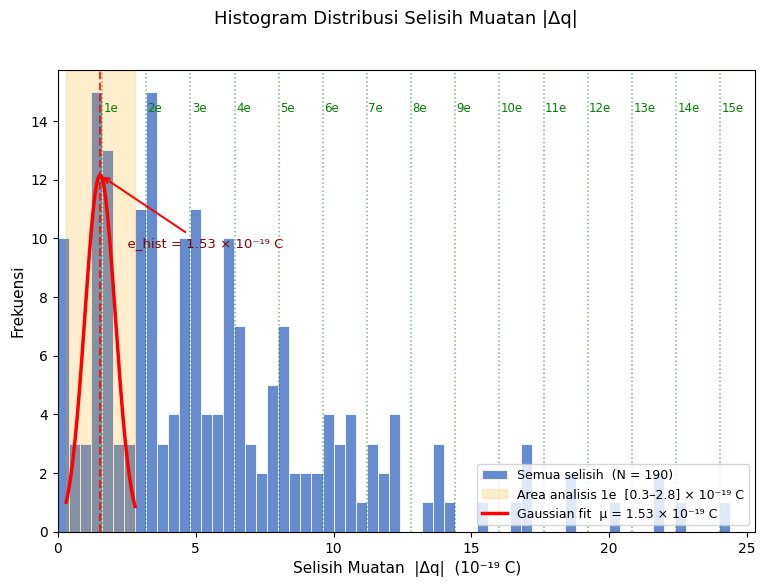

In [37]:
qavg = df_h['q_avg'].values
N = len(qavg)
diff_list = []

print('\n--- MATRIKS SELISIH |qi - qj| (x10^-19 C) - Segitiga Bawah ---')
print(f"{'':5s}", ''.join([f'{j:8d}' for j in range(1, N + 1)]))
print('-' * (5 + 8 * N))

for i in range(N):
    row_str = f'{i+1:3d}  '
    for j in range(N):
        if j < i:
            val = abs(qavg[i] - qavg[j])
            diff_list.append(val)
            row_str += f'{val*1e19:8.3f}'
        elif j == i:
            row_str += f'{"--":8s}'
        else:
            row_str += f'{"":8s}'
    print(row_str)

q_vals = df_h['q_avg'].values
n_data = len(q_vals)

selisih = np.array([
    abs(q_vals[i] - q_vals[j])
    for i in range(n_data)
    for j in range(i + 1, n_data)
])
selisih_19 = selisih / 1e-19

print(f"\n  Total data  : {len(selisih)}  [= {n_data}x({n_data}-1)/2]")
print(f"  Rentang selisih       : {selisih_19.min():.4f} - {selisih_19.max():.4f} x 10^-19 C")

bawah, atas = 0.3e-19, 2.8e-19
peak1       = selisih[(selisih >= bawah) & (selisih <= atas)]
peak1_19    = peak1 / 1e-19

mu_g, std_g = norm.fit(peak1_19)
SE_g        = std_g / np.sqrt(len(peak1))
galat_hist  = abs(mu_g - e_ref/1e-19) / (e_ref/1e-19) * 100

print(f"\n  Gaussian Fit (puncak 1e):")
print(f"    mu  (e_hist) = {mu_g:.4f} x 10^-19 C")
print(f"    sigma        = {std_g:.4f} x 10^-19 C")
print(f"    SE = s/sqrt({len(peak1)}) = {SE_g:.4f} x 10^-19 C")
print(f"\n  e_hist = ({mu_g:.2f} +/- {SE_g:.2f}) x 10^-19 C")
print(f"  Error e_hist = {galat_hist:.2f}%")

fig, ax1 = plt.subplots(figsize=(9, 6))
fig.suptitle(
    'Histogram Distribusi Selisih Muatan |Δq|\n',
    fontsize=13
)

bin_width = 0.4
bins_all  = np.arange(0, selisih_19.max() + bin_width, bin_width)

ax1.hist(selisih_19, bins=bins_all,
         color='#4472C4', edgecolor='white', linewidth=0.7,
         alpha=0.82, label=f'Semua selisih  (N = {len(selisih)})')

ax1.axvspan(bawah/1e-19, atas/1e-19, alpha=0.20, color='orange',
            label=f'Area analisis 1e  [{bawah/1e-19:.1f}–{atas/1e-19:.1f}] × 10⁻¹⁹ C')

x_fit = np.linspace(bawah/1e-19, atas/1e-19, 400)
scale = len(peak1) * bin_width
y_fit = norm.pdf(x_fit, mu_g, std_g) * scale
ax1.plot(x_fit, y_fit, 'r-', linewidth=2.5,
         label=f'Gaussian fit  μ = {mu_g:.2f} × 10⁻¹⁹ C')
ax1.axvline(mu_g, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

ax1.annotate(
    f'  e_hist = {mu_g:.2f} × 10⁻¹⁹ C',
    xy=(mu_g, norm.pdf(mu_g, mu_g, std_g) * scale),
    xytext=(mu_g + 0.7, norm.pdf(mu_g, mu_g, std_g) * scale * 0.80),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.4),
    fontsize=9.5, color='darkred'
)

for k in range(1, int(selisih_19.max() / (e_ref/1e-19)) + 2):
    xk = k * (e_ref / 1e-19)
    if xk > selisih_19.max() * 1.05:
        break
    ax1.axvline(xk, color='green', linestyle=':', linewidth=1.1, alpha=0.55)
    ax1.text(xk + 0.05, ax1.get_ylim()[1] * 0.93 if ax1.get_ylim()[1] > 0 else scale * 1.4,
             f'{k}e', color='green', fontsize=8.5, va='top')

ax1.set_xlabel('Selisih Muatan  |Δq|  (10⁻¹⁹ C)', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_xlim(0, selisih_19.max() * 1.05)
ax1.legend(fontsize=9, loc='lower right')

   REGRESI LINEAR  q = m·n + c

  Persamaan   : q = 1.5747·n + 0.1946  (x 10^-19 C)
  Gradien  m  = 1.5747 x 10^-19 C
  Intercept c = 0.1946 x 10^-19 C
  R²          = 0.9972
  Ralat Sm    = 0.0196 x 10^-19 C

  e_regr = (1.57 +/- 0.02) x 10^-19 C
  Galat e_regr = 1.70%


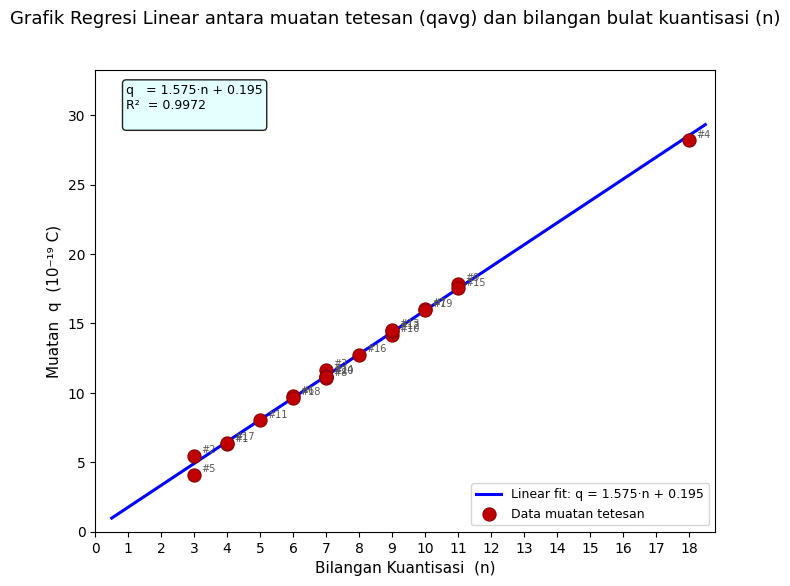

In [35]:
n_arr = df_h['n'].values.astype(float)
q_arr = df_h['q_avg'].values / 1e-19   # satuan 10^-19 C

koef  = np.polyfit(n_arr, q_arr, 1)
m_reg = koef[0]
c_reg = koef[1]

q_pred = np.polyval(koef, n_arr)
SS_res = np.sum((q_arr - q_pred) ** 2)
SS_tot = np.sum((q_arr - q_arr.mean()) ** 2)
R2     = 1 - SS_res / SS_tot

n_pts  = len(n_arr)
Sm     = np.sqrt(SS_res / (n_pts - 2)) / np.sqrt(np.sum((n_arr - n_arr.mean()) ** 2))
galat_regr = abs(m_reg - e_ref/1e-19) / (e_ref/1e-19) * 100

print("   REGRESI LINEAR  q = m·n + c")
print(f"\n  Persamaan   : q = {m_reg:.4f}·n + {c_reg:.4f}  (x 10^-19 C)")
print(f"  Gradien  m  = {m_reg:.4f} x 10^-19 C")
print(f"  Intercept c = {c_reg:.4f} x 10^-19 C")
print(f"  R²          = {R2:.4f}")
print(f"  Ralat Sm    = {Sm:.4f} x 10^-19 C")
print(f"\n  e_regr = ({m_reg:.2f} +/- {Sm:.2f}) x 10^-19 C")
print(f"  Galat e_regr = {galat_regr:.2f}%")

fig, ax2 = plt.subplots(figsize=(8, 6))
fig.suptitle(
    'Grafik Regresi Linear antara muatan tetesan (qavg) dan bilangan bulat kuantisasi (n)',
    fontsize=13
)

n_line = np.linspace(0.5, n_arr.max() + 0.5, 300)
q_line = np.polyval(koef, n_line)

ax2.plot(n_line, q_line, 'b-', linewidth=2.2,
         label=f'Linear fit: q = {m_reg:.3f}·n + {c_reg:.3f}')

ax2.scatter(n_arr, q_arr, color='#C00000', s=90, zorder=5,
            edgecolors='darkred', linewidth=0.8,
            label='Data muatan tetesan')

for _, row in df_h.iterrows():
    ax2.annotate(f"#{int(row['No'])}",
                 (row['n'], row['q_avg'] / 1e-19),
                 textcoords="offset points", xytext=(5, 2),
                 fontsize=7, color='#555')

info = (f'q   = {m_reg:.3f}·n + {c_reg:.3f}\n'
        f'R²  = {R2:.4f}\n')
ax2.text(0.05, 0.97, info, transform=ax2.transAxes,
         fontsize=9, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.88))

ax2.set_xlabel('Bilangan Kuantisasi  (n)', fontsize=11)
ax2.set_ylabel('Muatan  q  (10⁻¹⁹ C)', fontsize=11)
ax2.set_xticks(range(0, int(n_arr.max()) + 2))
ax2.set_xlim(0, n_arr.max() + 0.8)
ax2.set_ylim(0, q_arr.max() * 1.18)
ax2.legend(fontsize=9, loc='lower right')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00


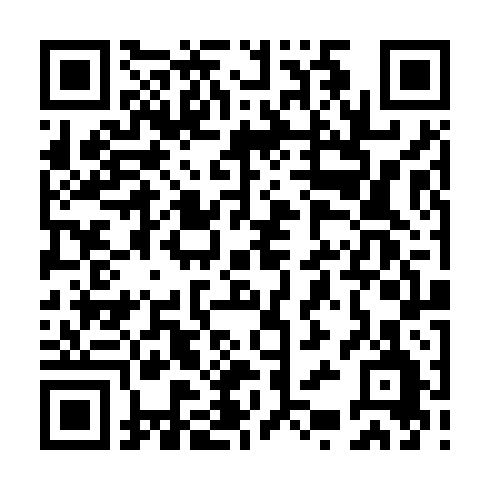

In [31]:
# Install library qrcode
!pip install qrcode[pil]

# Import library
import qrcode
from IPython.display import Image, display

# Ganti URL di bawah ini dengan link Google Colab yang kamu inginkan
link = "https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/MP2_millikan.ipynb"

# Buat QR code
qr = qrcode.make(link)

# Tampilkan QR code
qr.save("qrcode_colab.png")
display(Image(filename="qrcode_colab.png"))